# 01 — Data Exploration & Leakage Audit

Exploratory analysis of the built corpora and the train->eval leakage screen (proposal §1 EDA, §1.5 near-duplicate audit).

Consumes:
- `data/train_proposal/{train,val,cal}.jsonl` — schema `{input, label: safe|unsafe, channel, source}`
- `data/eval_proposal/eval.jsonl` — schema `{id, text, label: 0|1, category, channel, source}` (BASELINE_SPEC)

Two schemas differ (train `input`/`safe|unsafe`, eval `text`/`0|1`); Cell 2 unifies them.
This notebook is a QA gate: it asserts channel coverage and verifies the §1.5 filter left no
residual train->eval near-duplicates. Run `scripts/cross_eval_dedup.py` first so the audit reflects the filtered eval set.

## Cell 1 — Imports & paths

In [1]:
import os, sys, json, collections
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(os.path.abspath("")).resolve()
# Notebook lives in notebooks/; project root is its parent.
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

TRAIN_DIR = BASE_DIR / "data" / "train_proposal"
EVAL_PATH = BASE_DIR / "data" / "eval_proposal" / "eval.jsonl"
print("BASE_DIR :", BASE_DIR)
print("train dir:", TRAIN_DIR, "exists:", TRAIN_DIR.exists())
print("eval     :", EVAL_PATH, "exists:", EVAL_PATH.exists())

BASE_DIR : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid
train dir: /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/data/train_proposal exists: True
eval     : /Users/lenguyenminhhuy/study/thesis/experiments/cascade-pid/data/eval_proposal/eval.jsonl exists: True


## Cell 2 — Load & unify both corpora
Map train `label` safe/unsafe -> 0/1 and hyphenated channels to the eval channel vocabulary so the two
sides are directly comparable. `y` = 0 benign / 1 injection; `corpus` = train|eval; `split` = train/val/cal/eval.

In [2]:
def read_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

CHANNEL_NORM = {
    "document-embedded": "document", "tool-output": "tool",
    "application-structured": "application_structured",
    "conversational": "conversational", "direct": "direct",
    "document": "document", "tool": "tool", None: None,
}

rows = []
for fname in ["train.jsonl", "val.jsonl", "cal.jsonl"]:
    p = TRAIN_DIR / fname
    if not p.exists():
        print("MISSING", p); continue
    split = fname.split(".")[0]
    for r in read_jsonl(p):
        rows.append({
            "corpus": "train", "split": split, "text": r["input"],
            "y": 1 if r["label"] == "unsafe" else 0,
            "channel_raw": r.get("channel"),
            "channel": CHANNEL_NORM.get(r.get("channel"), r.get("channel")),
            "source": r.get("source"),
        })
for r in read_jsonl(EVAL_PATH):
    rows.append({
        "corpus": "eval", "split": "eval", "text": r["text"],
        "y": int(r["label"]), "channel_raw": r.get("channel"),
        "channel": CHANNEL_NORM.get(r.get("channel"), r.get("channel")),
        "source": r.get("source"),
    })

df = pd.DataFrame(rows)
df["n_tokens"] = df["text"].str.split().apply(len)
print("Total records:", len(df))
print(df.groupby("corpus").size().rename("n").to_string())

Total records: 82542
corpus
eval     25747
train    56795


## Cell 3 — Class balance & benign:injection ratio per split

In [3]:
bal = df.groupby(["corpus", "split", "y"]).size().unstack(fill_value=0)
bal.columns = ["benign(0)", "injection(1)"]
bal["total"] = bal.sum(axis=1)
bal["benign:inj"] = (bal["benign(0)"] / bal["injection(1)"].replace(0, np.nan)).round(2)
print(bal.to_string())

              benign(0)  injection(1)  total  benign:inj
corpus split                                            
eval   eval       18634          7113  25747        2.62
train  cal         2640          3082   5722        0.86
       train      21285         24064  45349        0.88
       val         2616          3108   5724        0.84


## Cell 4 — Channel distribution per split

In [4]:
chan = df.groupby(["corpus", "split", "channel"], dropna=False).size().unstack(fill_value=0)
print(chan.to_string())
print("\nEval injection channels present:",
      sorted(df[(df.corpus=="eval") & (df.y==1)]["channel"].dropna().unique().tolist()))

channel       application_structured  conversational  direct  document  tool    NaN
corpus split                                                                       
eval   eval                        0               0    2830      2819  1464  18634
train  cal                      1687             953     930      1908   244      0
       train                   13654            7631    6968     15089  2007      0
       val                      1659             957     899      1951   258      0

Eval injection channels present: ['direct', 'document', 'tool']


## Cell 5 — Source distribution per corpus

In [5]:
for corpus in ["train", "eval"]:
    sub = df[df.corpus == corpus]
    print(f"\n=== {corpus} sources ===")
    print(sub.groupby("source").size().sort_values(ascending=False).rename("n").to_string())


=== train sources ===
source
alpaca               16661
synthetic-encoded    14699
bipia                 9927
ultrachat             9000
struq_generated       4000
injecagent            1054
hackaprompt            574
ifeval                 541
notinject              339

=== eval sources ===
source
lmsys                   9452
dolly                   4891
natural_instructions    4291
struq_synthetic         2830
openpromptinjection     2819
agentdojo               1464


## Cell 6 — Channel coverage assertions (QA gate)

In [6]:
REQUIRED_TRAIN = {"conversational", "application_structured", "document", "tool", "direct"}
train_chan = set(df[df.corpus=="train"]["channel"].dropna().unique())
missing = REQUIRED_TRAIN - train_chan
assert not missing, f"Train missing channels: {missing}"
print("Train channel coverage OK:", sorted(train_chan))

REQUIRED_EVAL_INJ = {"document", "tool", "direct"}
eval_inj_chan = set(df[(df.corpus=="eval") & (df.y==1)]["channel"].dropna().unique())
missing_e = REQUIRED_EVAL_INJ - eval_inj_chan
assert not missing_e, f"Eval missing injection channels: {missing_e}"
print("Eval injection-channel coverage OK:", sorted(eval_inj_chan))

Train channel coverage OK: ['application_structured', 'conversational', 'direct', 'document', 'tool']
Eval injection-channel coverage OK: ['direct', 'document', 'tool']


## Cell 7 — Input-length distributions (whitespace-token proxy)

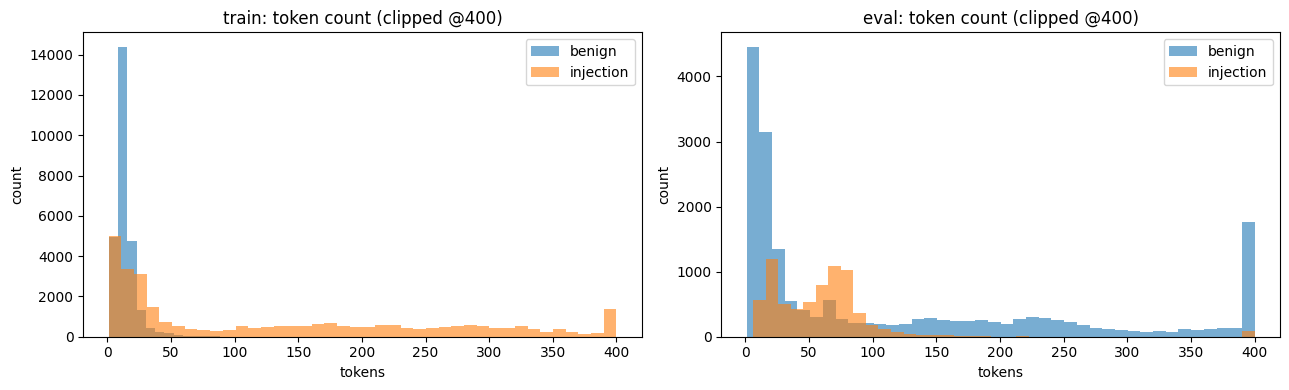

Median tokens by corpus/label:
corpus  y
eval    0    37.0
        1    60.0
train   0    12.0
        1    86.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, corpus in zip(axes, ["train", "eval"]):
    sub = df[df.corpus == corpus]
    ax.hist(np.clip(sub[sub.y==0]["n_tokens"], 0, 400), bins=40, alpha=0.6, label="benign")
    ax.hist(np.clip(sub[sub.y==1]["n_tokens"], 0, 400), bins=40, alpha=0.6, label="injection")
    ax.set_title(f"{corpus}: token count (clipped @400)")
    ax.set_xlabel("tokens"); ax.set_ylabel("count"); ax.legend()
plt.tight_layout(); plt.show()

print("Median tokens by corpus/label:")
print(df.groupby(["corpus", "y"])["n_tokens"].median().rename("median_tokens").to_string())

## Cell 8 — Per-channel length (eval injection channels)

In [8]:
ev = df[(df.corpus=="eval") & (df.y==1)]
print(ev.groupby("channel")["n_tokens"].describe()[["count","mean","50%","max"]].round(1).to_string())

           count  mean   50%    max
channel                            
direct    2830.0  37.0  23.0   93.0
document  2819.0  72.6  70.0  224.0
tool      1464.0  90.5  56.0  646.0


## Cell 9 — Leakage audit A: source disjointness
Train and eval must draw from disjoint sources (the OOD-by-source design). Any overlap is a red flag.

In [9]:
train_sources = set(df[df.corpus=="train"]["source"].dropna().unique())
eval_sources  = set(df[df.corpus=="eval"]["source"].dropna().unique())
overlap = train_sources & eval_sources
print("Train sources:", sorted(train_sources))
print("Eval  sources:", sorted(eval_sources))
print("\nOverlap:", sorted(overlap) if overlap else "(none — disjoint OK)")
assert not overlap, f"Source overlap between train and eval: {overlap}"

Train sources: ['alpaca', 'bipia', 'hackaprompt', 'ifeval', 'injecagent', 'notinject', 'struq_generated', 'synthetic-encoded', 'ultrachat']
Eval  sources: ['agentdojo', 'dolly', 'lmsys', 'natural_instructions', 'openpromptinjection', 'struq_synthetic']

Overlap: (none — disjoint OK)


## Cell 10 — Leakage audit B: train->eval near-duplicate screen
Reuses `scripts/cross_eval_dedup.find_near_dups` (char-5gram Jaccard >= 0.5 OR MiniLM cosine >= 0.95).
After running `scripts/cross_eval_dedup.py`, residual near-dups should be **0**. For notebook
responsiveness this samples the eval side; the authoritative full screen is the script.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

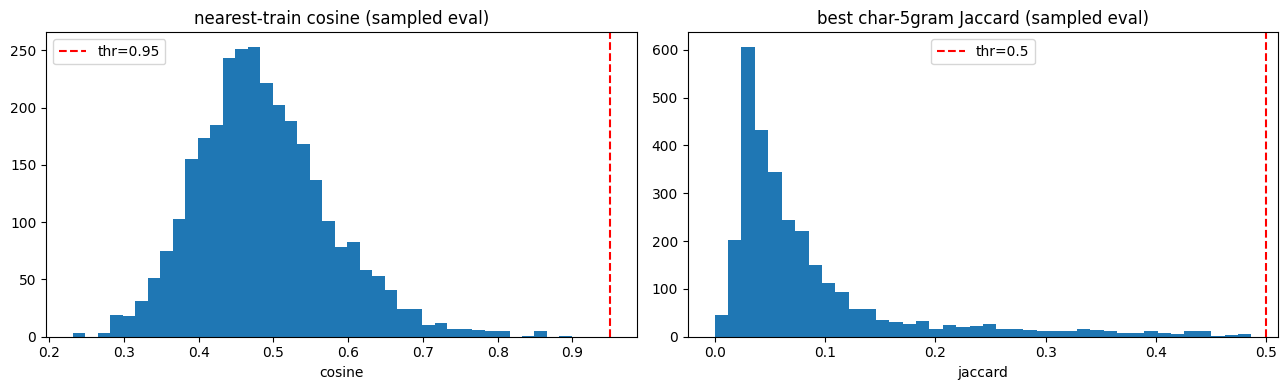

Sampled eval=3000 vs train=20000
Residual near-dups above threshold: 0
max cosine=0.8993  max jaccard=0.4865

No residual near-duplicates in sample — §1.5 screen holds.


In [10]:
from scripts.cross_eval_dedup import find_near_dups, COS_THRESHOLD, JAC_THRESHOLD

AUDIT_MAX_EVAL = 3000   # sample eval rows for the in-notebook plot; None = all
AUDIT_MAX_TRAIN = 20000 # sample train neighbours; None = all

tr = df[df.corpus=="train"]
ev = df[df.corpus=="eval"]
rng = np.random.default_rng(3131)
tr_idx = rng.choice(len(tr), min(AUDIT_MAX_TRAIN, len(tr)), replace=False) if AUDIT_MAX_TRAIN else np.arange(len(tr))
ev_idx = rng.choice(len(ev), min(AUDIT_MAX_EVAL, len(ev)), replace=False) if AUDIT_MAX_EVAL else np.arange(len(ev))
train_texts = tr["text"].iloc[tr_idx].tolist()
train_ids   = [f"{tr['split'].iloc[i]}:{i}" for i in tr_idx]
eval_texts  = ev["text"].iloc[ev_idx].tolist()

verdicts = find_near_dups(train_texts, train_ids, eval_texts, quiet=True)
cos = np.array([v["cos"] for v in verdicts])
jac = np.array([v["jac"] for v in verdicts])
n_removed = sum(v["remove"] for v in verdicts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cos, bins=40); axes[0].axvline(COS_THRESHOLD, color="r", ls="--", label=f"thr={COS_THRESHOLD}")
axes[0].set_title("nearest-train cosine (sampled eval)"); axes[0].set_xlabel("cosine"); axes[0].legend()
axes[1].hist(jac, bins=40); axes[1].axvline(JAC_THRESHOLD, color="r", ls="--", label=f"thr={JAC_THRESHOLD}")
axes[1].set_title("best char-5gram Jaccard (sampled eval)"); axes[1].set_xlabel("jaccard"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Sampled eval={len(eval_texts)} vs train={len(train_texts)}")
print(f"Residual near-dups above threshold: {n_removed}")
print(f"max cosine={cos.max():.4f}  max jaccard={jac.max():.4f}")
if n_removed:
    print("\nWARNING: residual leakage — run scripts/cross_eval_dedup.py.")
    for v in verdicts:
        if v["remove"]:
            print(" ", v)
else:
    print("\nNo residual near-duplicates in sample — §1.5 screen holds.")

## Cell 11 — Summary

In [11]:
print("=== CORPUS SUMMARY ===")
print(f"train: {len(df[df.corpus=='train'])} records "
      f"({int((df.corpus=='train').sum())} rows across train/val/cal)")
print(df[df.corpus=='train'].groupby('split').size().to_string())
print(f"\neval : {len(df[df.corpus=='eval'])} records")
print(bal.to_string() if 'bal' in dir() else '')
print("\nChannel coverage: train", sorted(set(df[df.corpus=='train'].channel.dropna())),
      "| eval-inj", sorted(set(df[(df.corpus=='eval')&(df.y==1)].channel.dropna())))
print("Source disjointness:", "OK" if not (set(df[df.corpus=='train'].source.dropna()) & set(df[df.corpus=='eval'].source.dropna())) else "VIOLATED")

=== CORPUS SUMMARY ===
train: 56795 records (56795 rows across train/val/cal)
split
cal       5722
train    45349
val       5724

eval : 25747 records
              benign(0)  injection(1)  total  benign:inj
corpus split                                            
eval   eval       18634          7113  25747        2.62
train  cal         2640          3082   5722        0.86
       train      21285         24064  45349        0.88
       val         2616          3108   5724        0.84

Channel coverage: train ['application_structured', 'conversational', 'direct', 'document', 'tool'] | eval-inj ['direct', 'document', 'tool']
Source disjointness: OK
